Import packages

In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import altair as alt
import pickle
import gdown
import matplotlib.pyplot as plt
import folium
from geopy.geocoders import Nominatim
import openrouteservice
import time
from tqdm import tqdm
import seaborn as sns
import openpyxl
import requests
from pandas_datareader import wb
from prophet import Prophet
from sklearn.metrics import mean_squared_log_error
from m_baseline_model import f_baseline_model
from m_prophet_model import f_prophet_model
from m_prophet_model_weekly import f_prophet_model_weekly
from m_metrics import f_asym_wmae
from m_train_test_cutoff import f_split_time_series


c:\Users\m.muller\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Get scoped sales file en features toevoegen

In [2]:
with open('C:\\Users\\m.muller\\Documents\\Python\\Projects\\Supermarket CFGS\\Data\\supermarket_scope_dairy.pkl', 'rb') as pickle_file:
    dc_scoped_df = pickle.load(pickle_file)
    sales_history = dc_scoped_df['df_processed']

sales_history['weight'] = np.where(sales_history['perishable'] == 1, 1.25, 1.0)
sales_history['weekday'] = sales_history['date'].dt.dayofweek
sales_history['quarter'] = sales_history['date'].dt.quarter

print(sales_history.head())
print()
print(sales_history.shape)

  onpromotion    month family   city      state type_store type_holiday  \
0         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
1         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
2         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
3         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
4         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   

       locale locale_name description transferred       date        id  \
0  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375666   
1  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375669   
2  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375677   
3  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375693   
4  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375701   

   store_nbr  item_nbr  unit_sales  day  class  perishable  cluster  \
0         44  122095.0         9.

Baseline model

In [4]:
#split data in train and test 
#sales_44 = sales_history[sales_history['store_nbr'] == 44]

train_df, test_df, cutoffdate  = f_split_time_series(sales_history, "date",118)

test_df = test_df.reset_index()

baseline_df = f_baseline_model(test_df)

wmae, total_sales, over_delivery, under_delivery = f_asym_wmae(baseline_df['unit_sales'], baseline_df['predicted_sales'])

print("WMAE:", wmae)
print("Total Sales:", total_sales)
print("Overdelivery:", over_delivery)
print("Underdelivery:", under_delivery)

print(baseline_df.shape)
print(f"the number of unique days is {baseline_df['date'].nunique()}")

# Create pickle file
baseline_forecast = {
'baseline_df': baseline_df,
}

with open('../data/baseline.pkl', 'wb') as pickle_file:
    pickle.dump(baseline_forecast, pickle_file)

Train/Val data: 2014-01-02 to 2017-04-19
Final Test data: 2017-04-20 to 2017-08-15
WMAE: 3.474759907104267
Total Sales: 1274679.0
Overdelivery: 274552.5
Underdelivery: 232640.0
(139240, 28)
the number of unique days is 90


Prophet model toepassen op train test data per item /store combinatie en asym WMEA berekenen

In [ ]:
all_forecasts = []

sales_44 = sales_history[sales_history['store_nbr'] == 44]

# Loop per winkel × item
for item, group in sales_44.groupby("item_nbr"):
    sales_filtered = group

    # Train/test split
    train_df, test_df, cutoffdate  = f_split_time_series(sales_filtered, "date")
    test_df = test_df.reset_index()
    train_df = train_df.reset_index()

    # Hernoem kolommen naar ds en y
    train_df = train_df.rename(columns={'date': 'ds', 'unit_sales': 'y'})
    test_df  = test_df.rename(columns={'date': 'ds', 'unit_sales': 'y'})


    # Init Prophet
    model = Prophet(
    )

    # Fit model
    model.fit(train_df)

    # Predict
    forecast = model.predict(test_df)

    # Voeg voorspellingen terug bij testdata
    test_with_preds = test_df.copy()
    test_with_preds['predicted_sales'] = forecast['yhat'].values
    test_with_preds['store_nbr'] = 44
    test_with_preds['item_nbr'] = item

    all_forecasts.append(test_with_preds)

# Samenvoegen
all_forecasts_df = pd.concat(all_forecasts, ignore_index=True)

# Asymmetrische WMAE
wmae, total_sales, over_delivery, under_delivery = f_asym_wmae(all_forecasts_df['y'], all_forecasts_df['predicted_sales'])

print("WMAE:", wmae)
print("Total Sales:", total_sales)
print("Overdelivery:", over_delivery)
print("Underdelivery:", under_delivery)


Grafiek afwijkingen

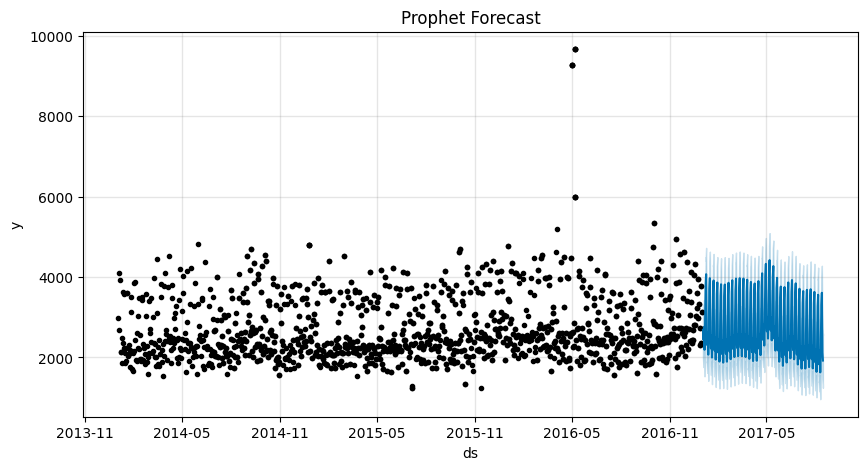

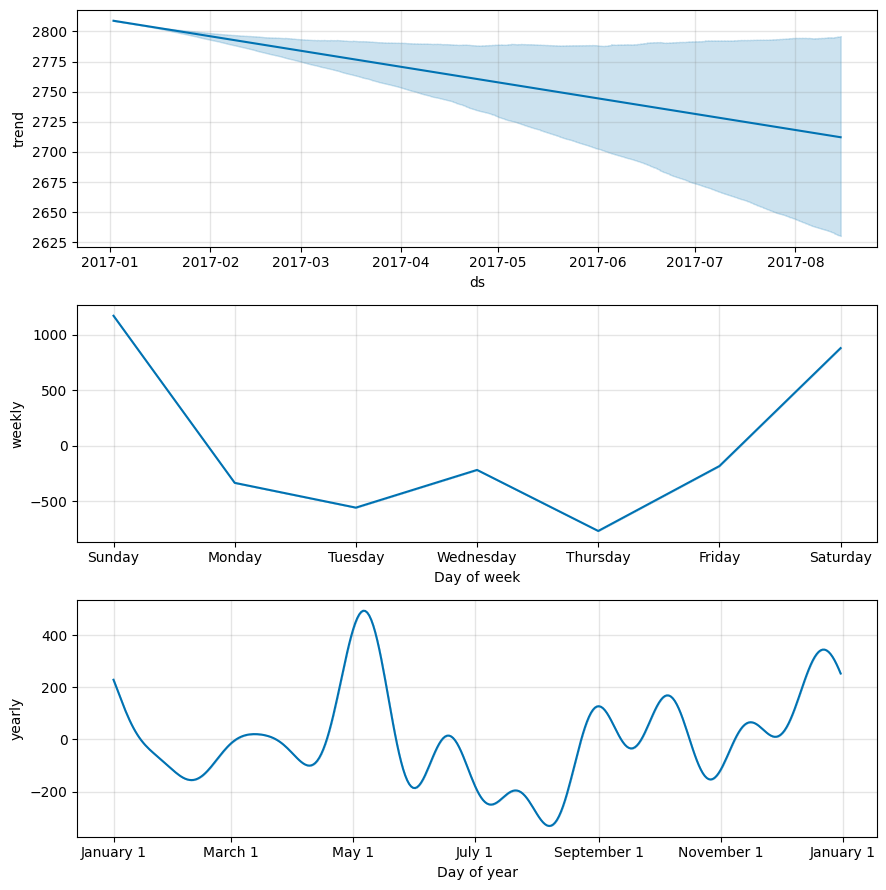

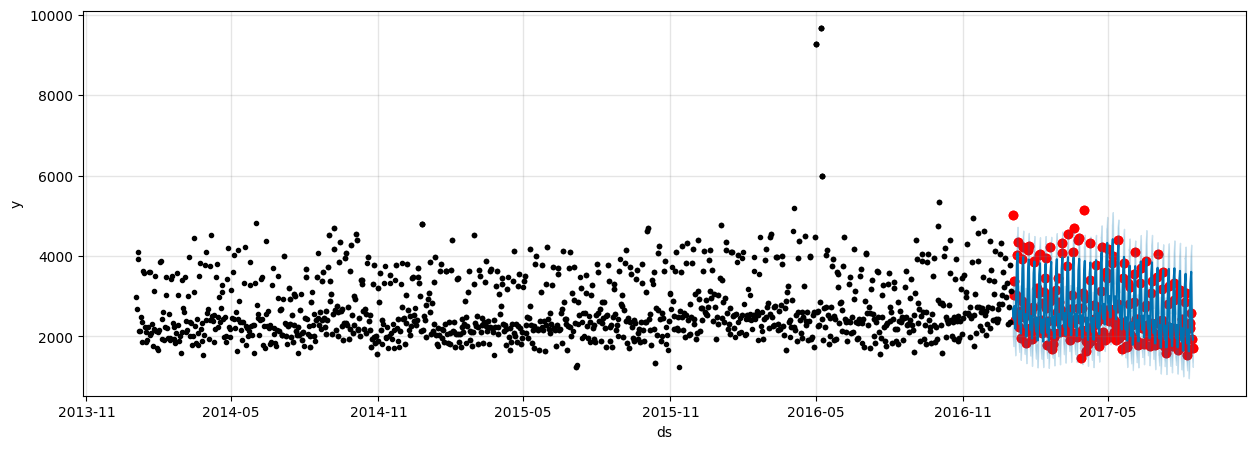

In [ ]:
#figuur met voorspellingen
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(forecast, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

#Figuur trends
fig = model.plot_components(forecast)
plt.show()

#forecast and actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df_prophet_test['ds'], df_prophet_test['y'], color='r')
fig = model.plot(forecast, ax=ax)


Prophet model toepassen op store level (dus totaal over items) en dan verdelen over items (gemiddelde verhouding zelfde werkdag laatste 4 weken)

In [3]:
# Train/test split
train_df, test_df, cutoffdate  = f_split_time_series(sales_history, "date")
test_df = test_df.reset_index()
train_df = train_df.reset_index()
    
# Eigen Prophet-parameters (optioneel)
my_prophet_params = {
    "yearly_seasonality": True,
    "weekly_seasonality": True,
    "daily_seasonality": True,
    "interval_width": 0.9,
    "changepoint_prior_scale": 0.05,   # gevoeliger voor trendveranderingen
    "seasonality_prior_scale": 5.0,    # minder sterke seizoenseffecten
}

# Aanroep van de functie
prophet_df = f_prophet_model_weekly(
    sales_history=sales_history,
    train=train_df,
    test=test_df,
    prophet_kwargs=my_prophet_params
)

prophet_df = prophet_df.rename(columns={'yhat_item': 'predicted_sales'})

#Asymmetrische WMAE
wmae, total_sales, over_delivery, under_delivery = f_asym_wmae(prophet_df['unit_sales'], prophet_df['predicted_sales'])

print("WMAE:", wmae)
print("Total Sales:", total_sales)
print("Overdelivery:", over_delivery)
print("Underdelivery:", under_delivery)

print(prophet_df.shape)
print(f"the number of unique days is {prophet_df['date'].nunique()}")



Train/Val data: 2014-01-02 to 2017-05-17
Final Test data: 2017-05-18 to 2017-08-15


Forecast per store (week):   0%|          | 0/8 [00:00<?, ?it/s]17:29:46 - cmdstanpy - INFO - Chain [1] start processing
17:29:47 - cmdstanpy - INFO - Chain [1] done processing
Forecast per store (week):  12%|█▎        | 1/8 [00:01<00:11,  1.66s/it]17:29:47 - cmdstanpy - INFO - Chain [1] start processing
17:29:47 - cmdstanpy - INFO - Chain [1] done processing
Forecast per store (week):  25%|██▌       | 2/8 [00:02<00:05,  1.11it/s]17:29:47 - cmdstanpy - INFO - Chain [1] start processing
17:29:47 - cmdstanpy - INFO - Chain [1] done processing
Forecast per store (week):  38%|███▊      | 3/8 [00:02<00:03,  1.44it/s]17:29:48 - cmdstanpy - INFO - Chain [1] start processing
17:29:48 - cmdstanpy - INFO - Chain [1] done processing
Forecast per store (week):  50%|█████     | 4/8 [00:02<00:02,  1.76it/s]17:29:48 - cmdstanpy - INFO - Chain [1] start processing
17:29:48 - cmdstanpy - INFO - Chain [1] done processing
Forecast per store (week):  62%|██████▎   | 5/8 [00:03<00:01,  2.03it/s]17:29:49 - 

WMAE: 3.469543020365959
Total Sales: 1274762.0
Overdelivery: 253847.0296513978
Underdelivery: 221060.29684369088
(136436, 8)
the number of unique days is 90


Prophet corrigeren voor incomplete weken naar baseline

In [9]:
baseline_df['item_nbr'] = baseline_df['item_nbr'].astype(str)
prophet_df['item_nbr']  = prophet_df['item_nbr'].astype(str)

baseline_df['store_nbr'] = baseline_df['store_nbr'].astype(int)
prophet_df['store_nbr']  = prophet_df['store_nbr'].astype(int)

# Merge beide tabellen
merged_df = pd.merge(
    baseline_df[['date', 'item_nbr', 'store_nbr', 'unit_sales', 'predicted_sales']],
    prophet_df[['date', 'item_nbr', 'store_nbr', 'predicted_sales']],
    on= ['date', 'item_nbr', 'store_nbr'],
    how='inner',
    suffixes=('_baseline', '_prophet')
)

# Zorg dat date datetime is
merged_df['date'] = pd.to_datetime(merged_df['date'])

# Bereken week en aantal dagen per week per store
merged_df['week'] = merged_df['date'].dt.to_period('W').apply(lambda x: x.start_time)

# Bereken aantal unieke dagen per week per store
week_counts = merged_df.groupby(['store_nbr','week'])['date'].nunique().reset_index(name='days_in_week')

# Markeer incomplete weken (minder dan 7 dagen)
incomplete_weeks = week_counts[week_counts['days_in_week'] < 7]


# Markeer incomplete weken (minder dan 7 dagen)
incomplete_weeks = week_counts[week_counts['days_in_week'] < 7]

# Maak een set van tuples (store, week) voor snelle lookup
incomplete_set = set(zip(incomplete_weeks['store_nbr'], incomplete_weeks['week']))

# Overschrijven van Prophet voorspelling met baseline voor incomplete weken
def replace_incomplete(row):
    if (row['store_nbr'], row['week']) in incomplete_set:
        return row['predicted_sales_baseline']
    else:
        return row['predicted_sales_prophet']

merged_df['predicted_sales_prophet'] = merged_df.apply(replace_incomplete, axis=1)

print(f"the number of unique store-item combinations is {merged_df[['store_nbr', 'item_nbr']].drop_duplicates().shape[0]}")
print(f"the number of unique items is {merged_df['item_nbr'].nunique()}")
print(f"the number of unique stores is {merged_df['store_nbr'].nunique()}")
print(f"the number of unique days is {merged_df['date'].nunique()}")

#Asymmetrische WMAE
wmae, total_sales, over_delivery, under_delivery = f_asym_wmae(merged_df['unit_sales'], merged_df['predicted_sales_prophet'])

print("WMAE:", wmae)
print("Total Sales:", total_sales)
print("Overdelivery:", over_delivery)
print("Underdelivery:", under_delivery)


the number of unique store-item combinations is 1583
the number of unique items is 203
the number of unique stores is 8
the number of unique days is 90
WMAE: 2.749730688994622
Total Sales: 1274679.0
Overdelivery: 167347.89136367984
Underdelivery: 234912.96298771998


Grafiek met vergelijk werkelijk, baseline en prophet over testdata

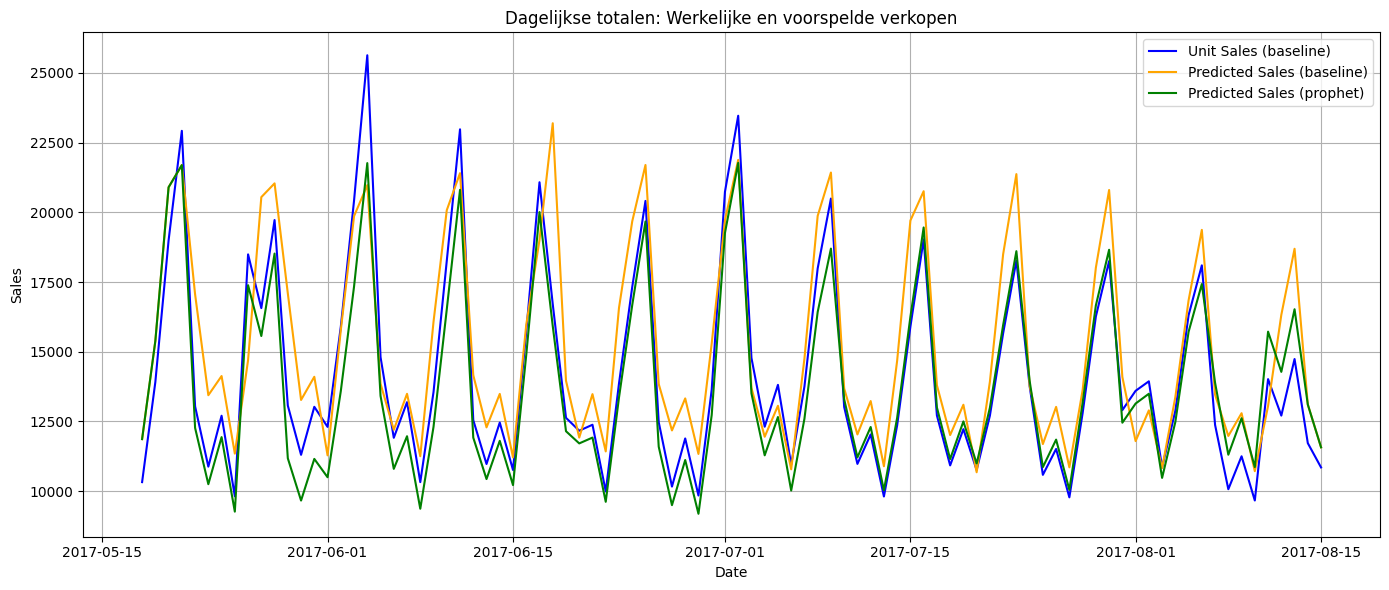

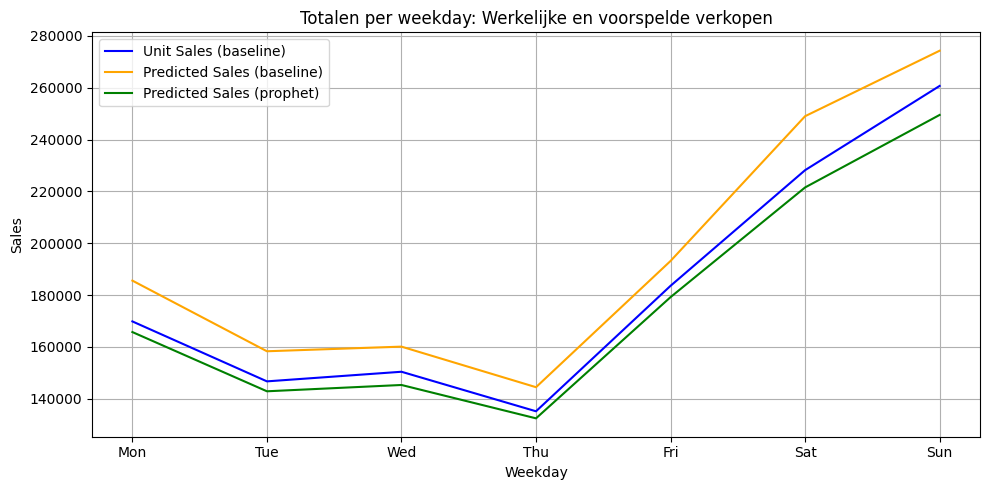

In [10]:
# Groepeer per dag en tel alles op
daily_sum = merged_df.groupby('date').agg({
    'unit_sales': 'sum',
    'predicted_sales_baseline': 'sum',
    'predicted_sales_prophet': 'sum'
}).reset_index()

# Plotten
plt.figure(figsize=(14,6))
plt.plot(daily_sum['date'], daily_sum['unit_sales'], label='Unit Sales (baseline)', color='blue')
plt.plot(daily_sum['date'], daily_sum['predicted_sales_baseline'], label='Predicted Sales (baseline)', color='orange')
plt.plot(daily_sum['date'], daily_sum['predicted_sales_prophet'], label='Predicted Sales (prophet)', color='green')

plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Dagelijkse totalen: Werkelijke en voorspelde verkopen')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Voeg weekday toe (0=maandag, 6=zondag)
merged_df['weekday'] = merged_df['date'].dt.weekday

# Groepeer per weekday en tel alles op
weekday_sum = merged_df.groupby('weekday').agg({
    'unit_sales': 'sum',
    'predicted_sales_baseline': 'sum',
    'predicted_sales_prophet': 'sum'
}).reset_index()

# Optioneel: zet weekday nummers om naar namen
weekday_sum['weekday_name'] = weekday_sum['weekday'].map({
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
})

# Plotten
plt.figure(figsize=(10,5))
plt.plot(weekday_sum['weekday_name'], weekday_sum['unit_sales'], label='Unit Sales (baseline)', color='blue')
plt.plot(weekday_sum['weekday_name'], weekday_sum['predicted_sales_baseline'], label='Predicted Sales (baseline)', color='orange')
plt.plot(weekday_sum['weekday_name'], weekday_sum['predicted_sales_prophet'], label='Predicted Sales (prophet)', color='green')

plt.xlabel('Weekday')
plt.ylabel('Sales')
plt.title('Totalen per weekday: Werkelijke en voorspelde verkopen')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()